In [5]:
import sys
sys.path.append("/global/u1/r/rmastand/mlpf-ssl/particlemind")

In [6]:
import numpy as np
import matplotlib.pyplot as plt

import awkward as ak

from src.datasets.CLDHits import CLDHitsSingleFile, inverse_standardize_calo_hit_features
from src.models.vqvae import VQVAELightning
from src.datasets.utils import Collater
from torch.utils.data import DataLoader



In [34]:
path_to_original_calo = "/pscratch/sd/r/rmastand/particlemind/data/p8_ee_tt_ecm365_parquetfiles/reco_p8_ee_tt_ecm365_60070.parquet"
path_to_generated_calo = "/pscratch/sd/r/rmastand/particlemind/data/generated_parquetfiles/generated_0.parquet"
path_to_generated_tokens = "/pscratch/sd/r/rmastand/particlemind/tokens/generated_parquetfiles/generated_0.parquet"

path_to_embedder_checkpoint = "/pscratch/sd/r/rmastand/particlemind/vqvae_training/best_models/embedder_test_val_loss_epoch=27.ckpt"

In [35]:
original_calo = ak.from_parquet(path_to_original_calo)
generated_calo = ak.from_parquet(path_to_generated_calo)
generated_tokens = ak.from_parquet(path_to_generated_tokens)


[[0, 426, 2, 216, 13, 384, 384, 83, 291, 173, 330, 513], ..., [0, 66, ..., 513]]


# Apply embedder to original data

tokenize and reconstruct

In [9]:
# load in embedder

embedder = VQVAELightning.load_from_checkpoint(
           path_to_embedder_checkpoint,
        )


file_dataset = CLDHitsSingleFile(path_to_original_calo, by_event=True)

file_loader = DataLoader(
    file_dataset,
    batch_size=2,
    collate_fn=Collater(empty_key="calo_hit_features", variable_size_keys="all"),
    num_workers=0,
    shuffle=False
)

features_x, features_y, features_z, features_e, hit_labels =  ak.Array([]), ak.Array([]), ak.Array([]), ak.Array([]), ak.Array([])  
reco_x, reco_y, reco_z, reco_e = ak.Array([]), ak.Array([]), ak.Array([]), ak.Array([])
tokens = ak.Array([])
for i, x_batch in enumerate(file_loader):

    print(i)


    if i > 5:
        break

    # move to device
    features_batch = x_batch["calo_hit_features"].to(embedder.device)
    mask_batch = x_batch["mask"].to(embedder.device)
    x_particle_reco, vq_out = embedder.forward(features_batch, mask_batch)

    for row in range(x_particle_reco.shape[0]):

        features_event = x_batch["calo_hit_features"][row]
        reco_event = x_particle_reco[row].detach().cpu().numpy()
        mask_event = mask_batch[row].int().detach().cpu().numpy()
        tokens_event = vq_out["q"][row].detach().cpu().numpy().reshape(-1,)
        labels_event = x_batch["hit_labels"][row]
        #event = inverse_standardize_calo_hit_features(event)

        features_x = ak.concatenate([features_x, ak.Array([features_event[:,0][mask_event==1]])], axis = 0)
        features_y = ak.concatenate([features_y, ak.Array([features_event[:,1][mask_event==1]])], axis = 0)
        features_z = ak.concatenate([features_z, ak.Array([features_event[:,2][mask_event==1]])], axis = 0)
        features_e = ak.concatenate([features_e, ak.Array([features_event[:,3][mask_event==1]])], axis = 0)

        hit_labels = ak.concatenate([hit_labels, ak.Array([labels_event[mask_event==1]])], axis = 0)

        reco_x = ak.concatenate([reco_x, ak.Array([reco_event[:,0][mask_event==1]])], axis = 0)
        reco_y = ak.concatenate([reco_y, ak.Array([reco_event[:,1][mask_event==1]])], axis = 0)
        reco_z = ak.concatenate([reco_z, ak.Array([reco_event[:,2][mask_event==1]])], axis = 0)
        reco_e = ak.concatenate([reco_e, ak.Array([reco_event[:,3][mask_event==1]])], axis = 0)

        tokens =  ak.concatenate([tokens, ak.Array([tokens_event[mask_event==1]])], axis = 0)



/pscratch/sd/r/rmastand/particlemind_env/lib/python3.8/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/pscratch/sd/r/rmastand/particle

0
1
2
3
4
5
6


In [37]:
gen_x, gen_y, gen_z, gen_e =  ak.Array([]), ak.Array([]), ak.Array([]), ak.Array([])
gen_tokens = ak.Array([])

for gen_event_i in range(len(generated_calo)):

    gen_x = ak.concatenate([gen_x, ak.Array([[hit[0] for hit in generated_calo[gen_event_i]]])], axis = 0)
    gen_y = ak.concatenate([gen_y, ak.Array([[hit[1] for hit in generated_calo[gen_event_i]]])], axis = 0)
    gen_z = ak.concatenate([gen_z, ak.Array([[hit[2] for hit in generated_calo[gen_event_i]]])], axis = 0)
    gen_e = ak.concatenate([gen_e, ak.Array([[hit[3] for hit in generated_calo[gen_event_i]]])], axis = 0)
    gen_tokens = ak.concatenate([gen_tokens, ak.Array([generated_tokens[gen_event_i][1:-1] -1 ])], axis = 0)

print(gen_tokens)

[[425, 1, 215, 12, 383, 383, 82, 290, 172, 329], ..., [65, 445, ..., 80, 67]]


In [28]:
features_original = {
   0: features_x,
   1: features_y,
   2: features_z,
    3: features_e
}

features_reconstructed = {
   0: reco_x,
   1: reco_y,
   2: reco_z,
    3: reco_e
  }

features_generated = {
    0: gen_x,
    1:  gen_y,
    2:  gen_z,
    3:  gen_e,
}

# Plot multiple events


In [30]:
position_lim = 0.5
e_lim = -1, 1

## x, y, z, e (1d)

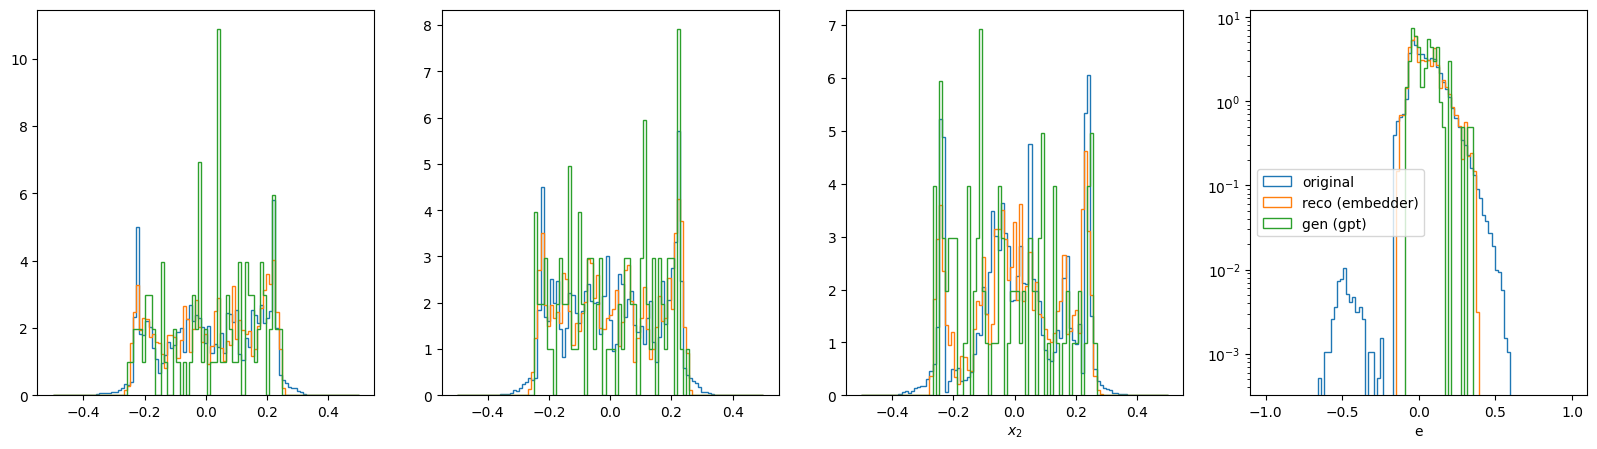

In [31]:
# calo

nbins = 100

fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(3):

    ax[i].hist(ak.flatten(features_original[i]), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "original", density=True)
    ax[i].hist(ak.flatten(features_reconstructed[i]), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)
    ax[i].hist(ak.flatten(features_generated[i]), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "gen (gpt)", density=True)

    ax[i].set_xlabel(f"$x_{i}$")

ax[3].hist(ak.flatten(features_original[3]), bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "original", density=True)
ax[3].hist(ak.flatten(features_reconstructed[3]), bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "reco (embedder)", density=True)
ax[3].hist(ak.flatten(features_generated[3]), bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "gen (gpt)", density=True)
ax[3].set_xlabel("e")
ax[3].set_yscale("log")
ax[3].legend()

ax[0].set_ylabel("Density")

plt.show()

# E resolution

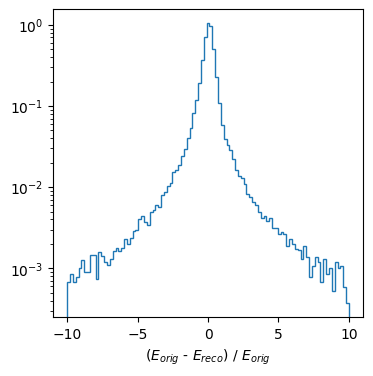

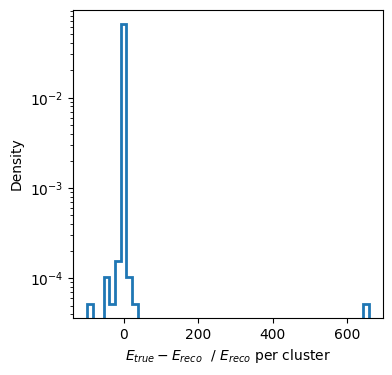

In [32]:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
ax.hist((ak.flatten(features_e) - ak.flatten(reco_e))/ak.flatten(features_e), bins = np.linspace(-10, 10, nbins), histtype = "step", label = "original", density=True)
ax.set_xlabel("($E_{orig}$ - $E_{reco}$) / $E_{orig}$")
ax.set_ylabel("Density")
ax.set_yscale("log")
plt.show()



fig, ax = plt.subplots(1, 1, figsize = (4, 4))


unique_labels = [np.unique(l.to_numpy()) for l in hit_labels]
hit_clusters_true, hit_clusters_reco = [], []
for event_i, hit_labels_event_i in enumerate(hit_labels):
    for unique_label_event_i in unique_labels[event_i]:
        mask = hit_labels_event_i == unique_label_event_i
   
        hit_clusters_true.append(np.sum(features_e[event_i][mask]))
        hit_clusters_reco.append(np.sum(reco_e[event_i][mask]))

ax.hist((np.array(hit_clusters_true) - np.array(hit_clusters_reco))/np.array(hit_clusters_true), bins=50, density=True, histtype="step", linewidth=2)
ax.set_xlabel( "$E_{true} - E_{reco}$  / $E_{reco}$ per cluster")
ax.set_ylabel("Density")
ax.set_ylabel("Density")
ax.set_yscale("log")
#ax.legend(loc="upper right")


# tokens

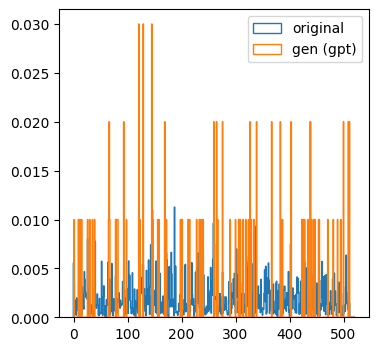

In [39]:
# tokens

fig, ax = plt.subplots(1, 1, figsize = (4, 4))
ax.hist(ak.flatten(tokens), bins = np.arange(-0.5, 522.5, 1), histtype = "step", label = "original", density = True)
ax.hist(ak.flatten(gen_tokens),  bins = np.arange(-0.5, 522.5, 1), histtype = "step", label = "gen (gpt)", density = True)
ax.set_xlabel("Token index")
ax.set_ylabel("Density")
ax.legend()
plt.show()

# Plot single events

## x, y, z, e (1d)

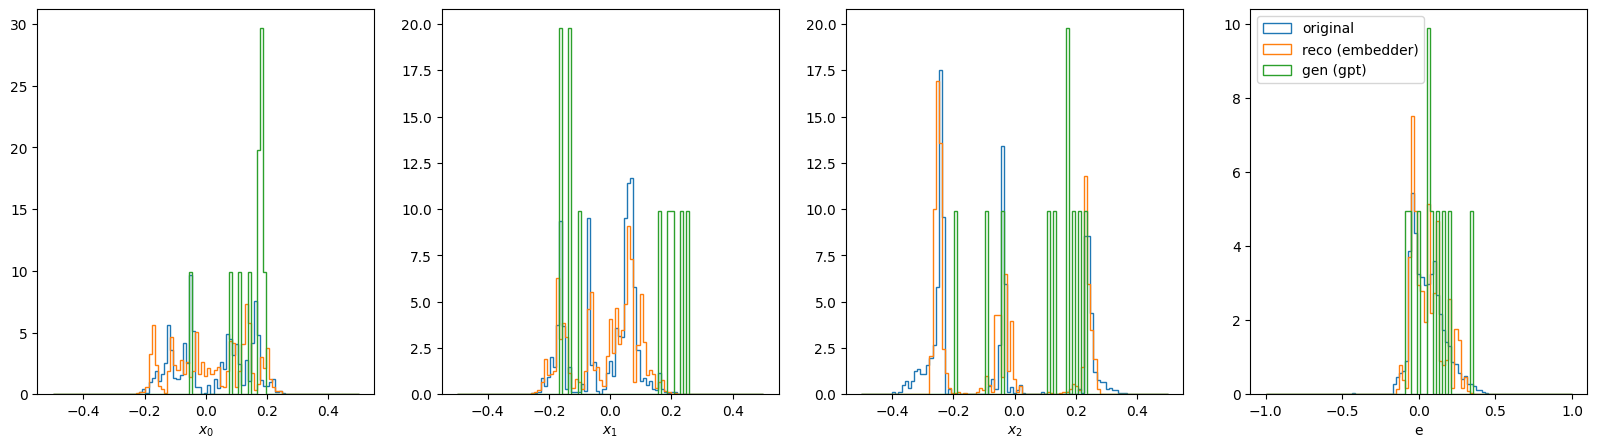

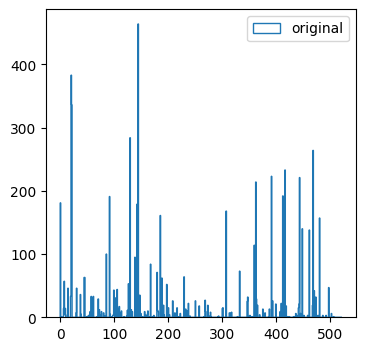

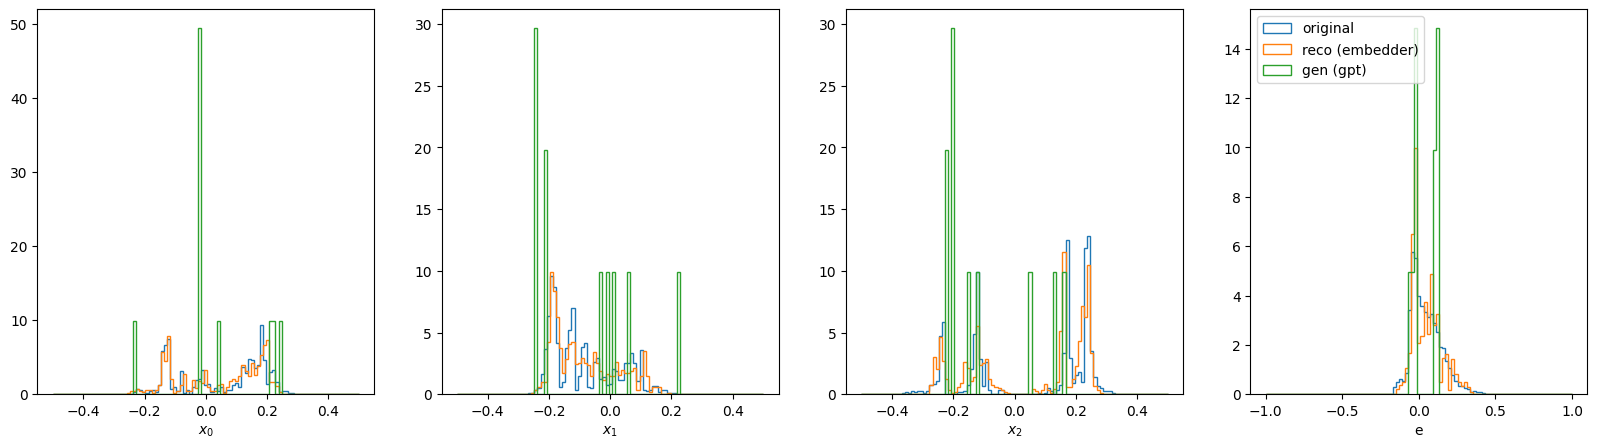

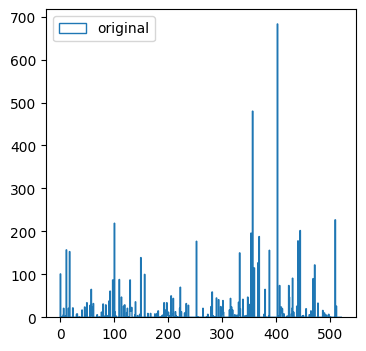

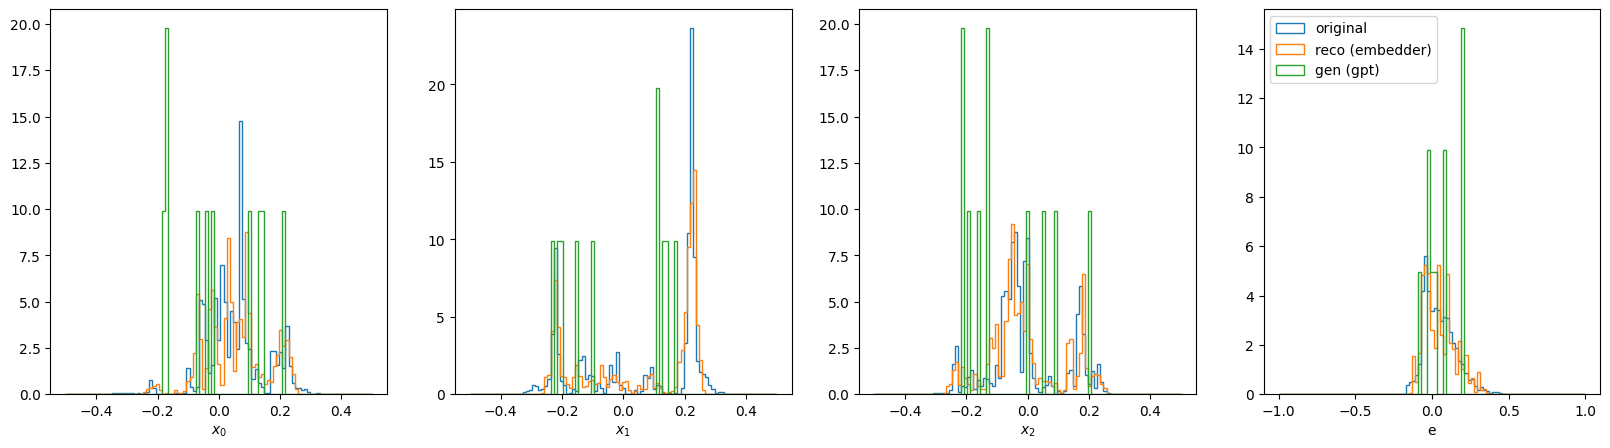

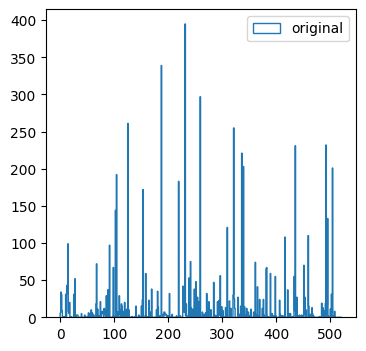

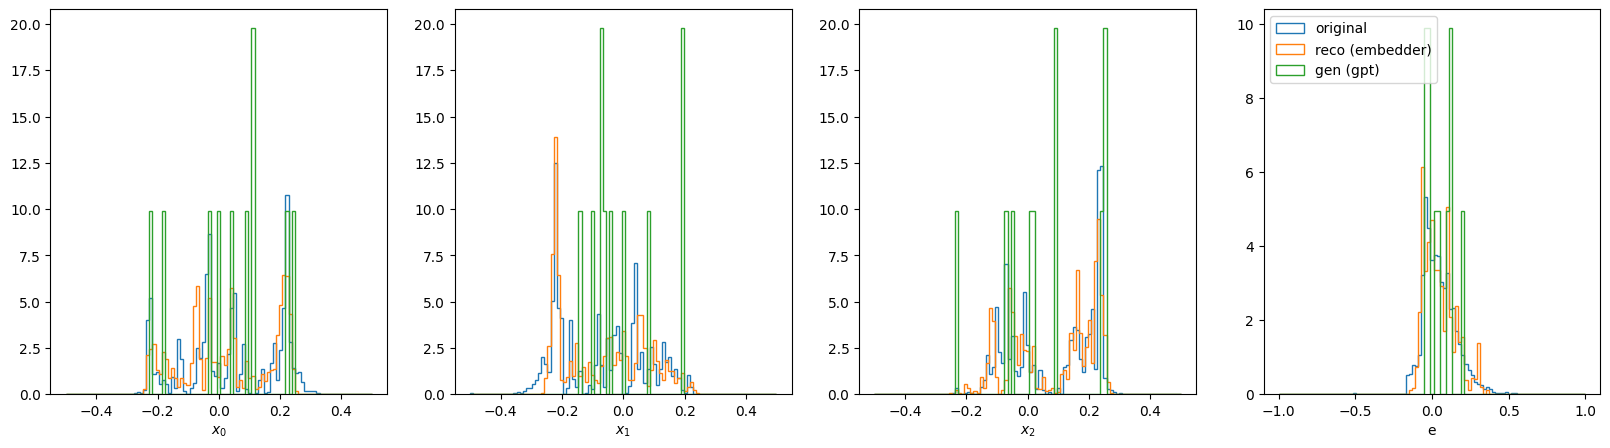

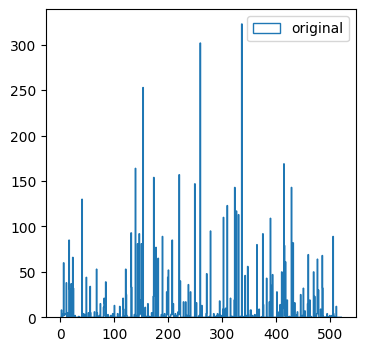

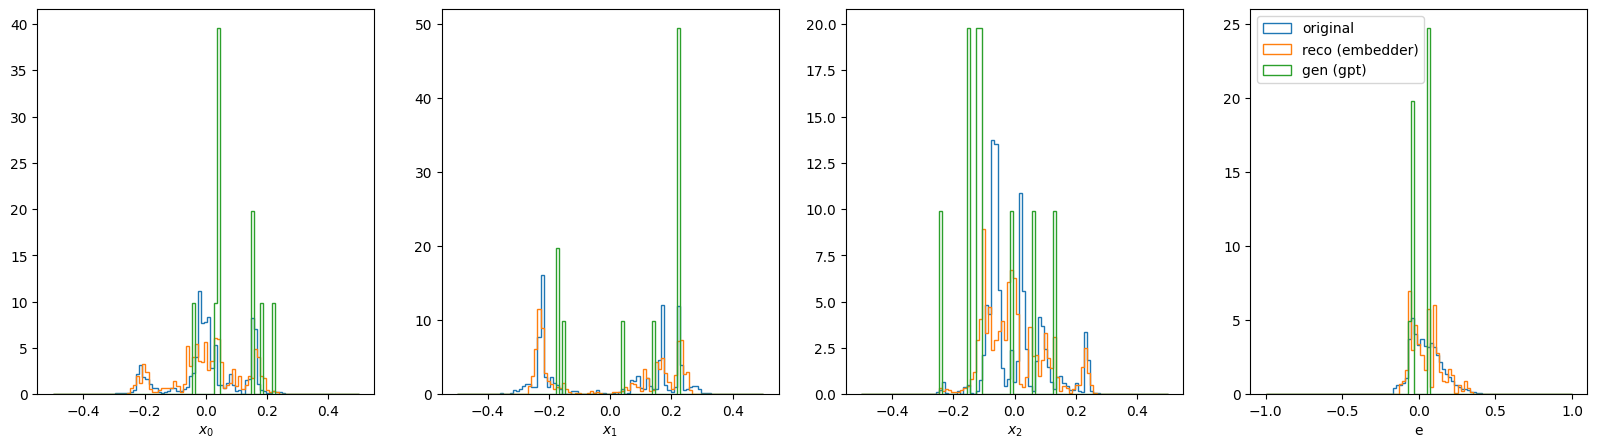

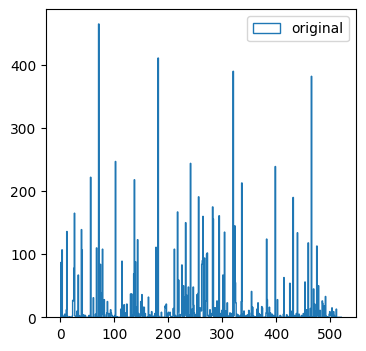

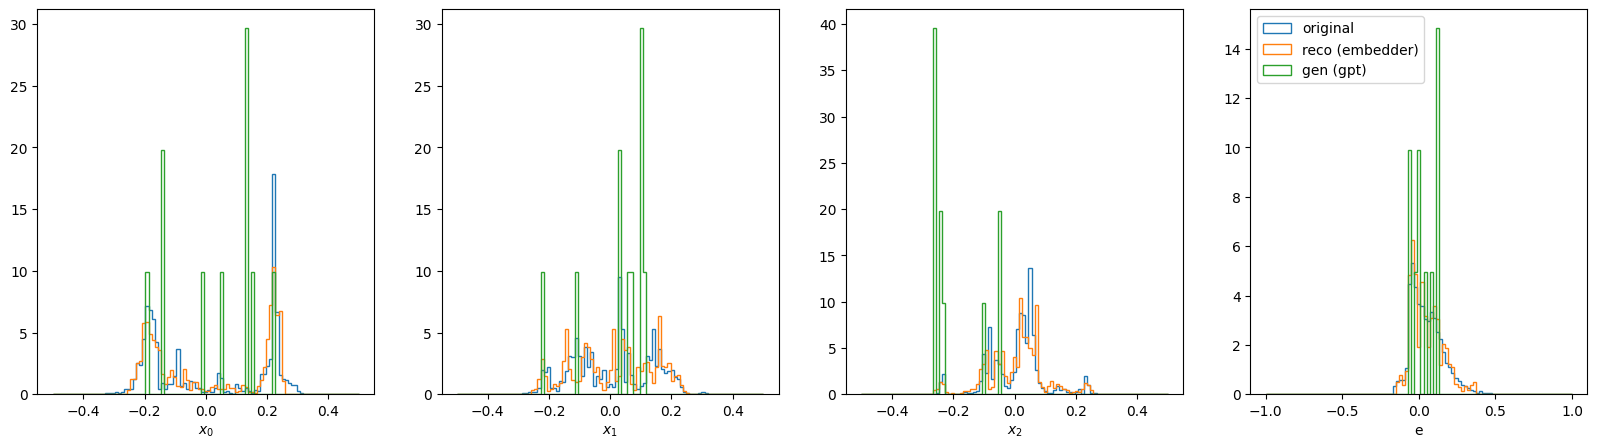

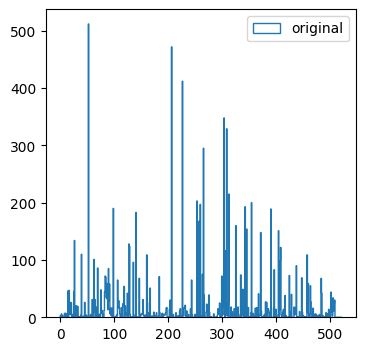

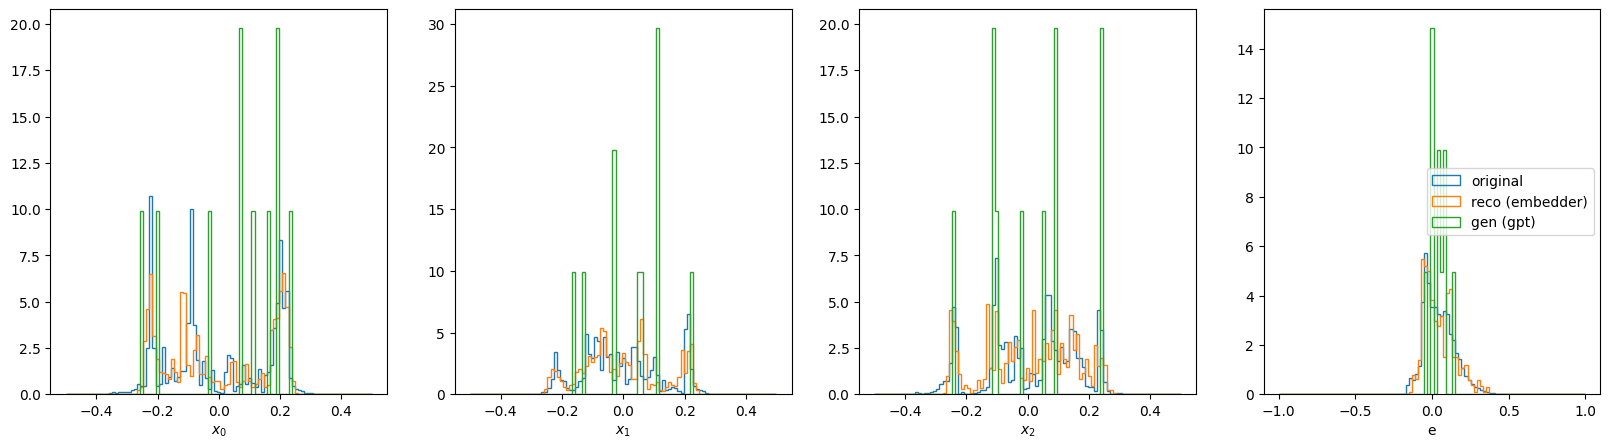

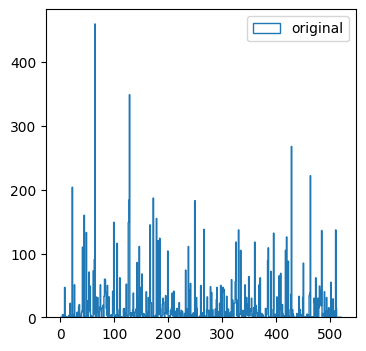

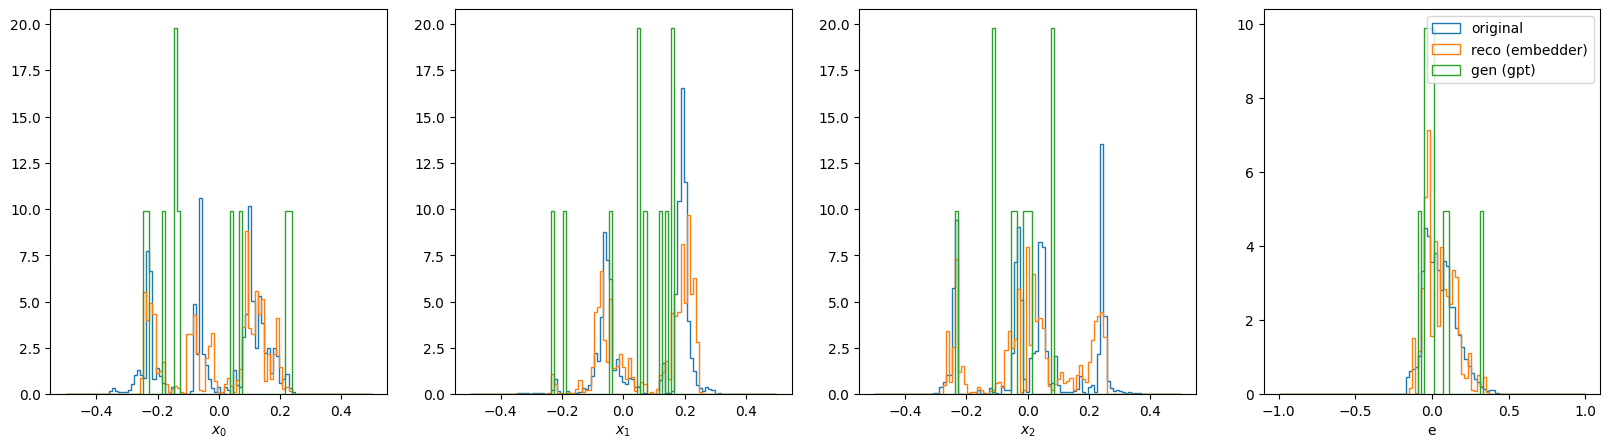

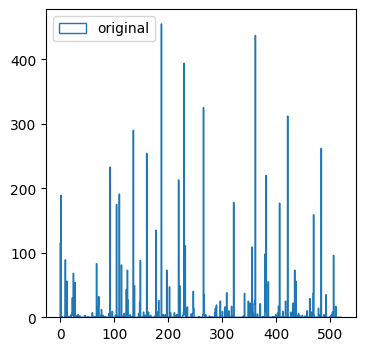

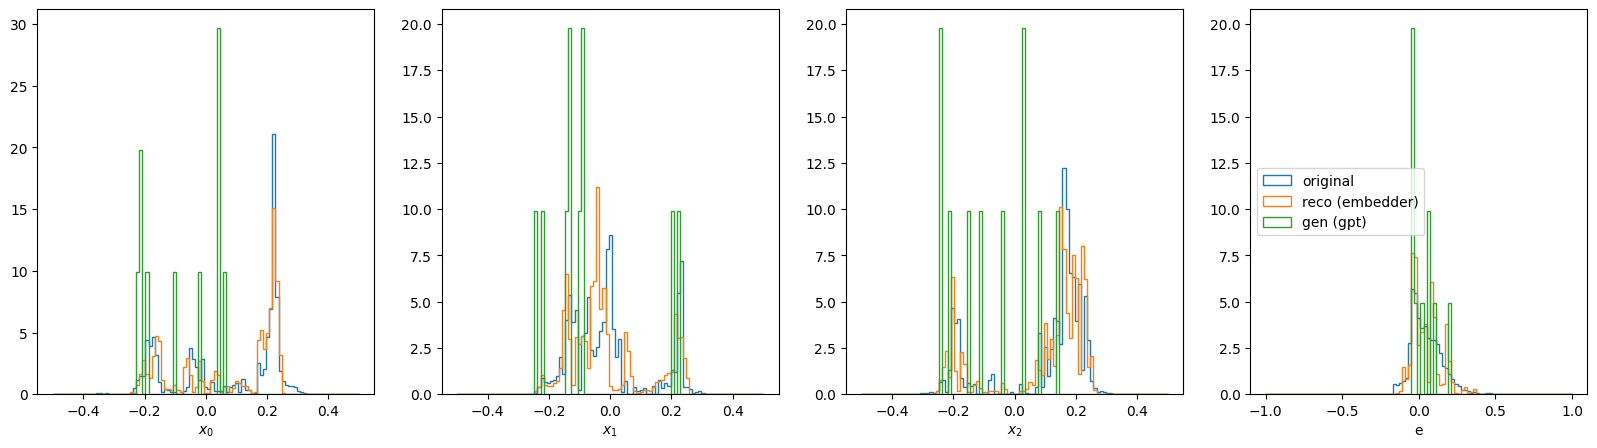

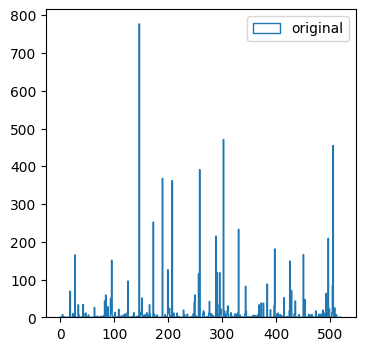

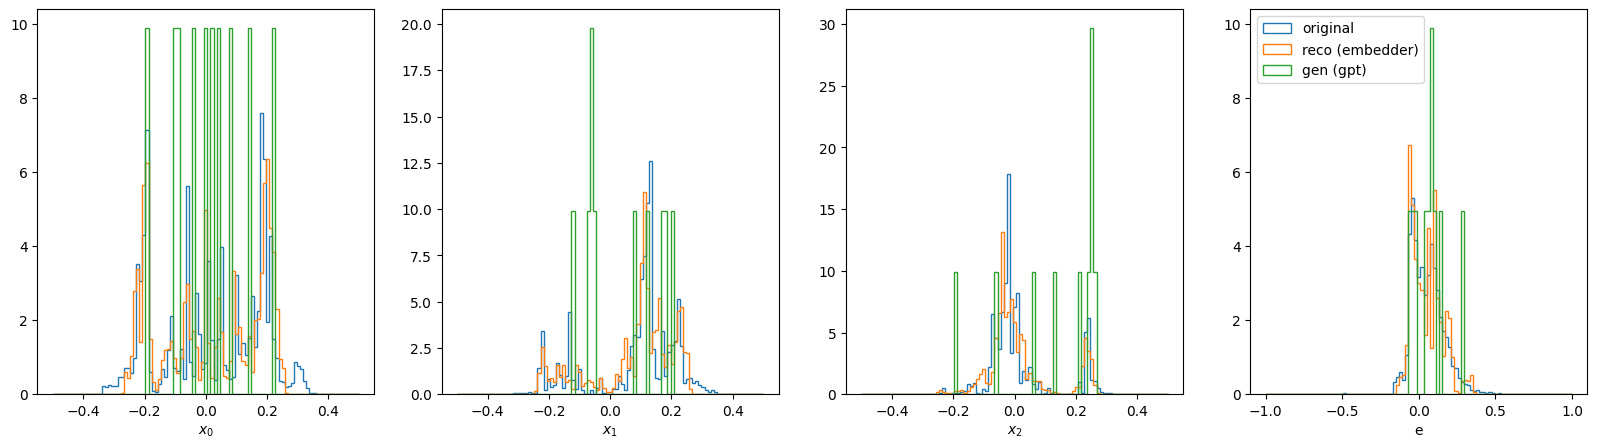

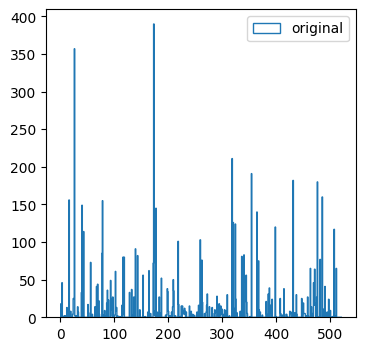

In [44]:
nbins = 100


for event_i in range(10):

    fig, ax = plt.subplots(1, 4, figsize = (20, 5))

    for i in range(3):

        ax[i].hist(features_original[i][event_i], bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "original", density=True)
        ax[i].hist(features_reconstructed[i][event_i], bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)
        ax[i].hist(features_generated[i][event_i], bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "gen (gpt)", density=True)

        ax[i].set_xlabel(f"$x_{i}$")
    

    ax[3].hist(features_original[3][event_i], bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "original", density=True)
    ax[3].hist(features_reconstructed[3][event_i], bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "reco (embedder)", density=True)
    ax[3].hist(features_generated[3][event_i], bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "gen (gpt)", density=True)

    ax[3].set_xlabel("e")
    ax[3].legend()

    ax[0].set_ylabel("Density")

    
    plt.show()


    fig, ax = plt.subplots(1, 1, figsize = (4, 4))
    ax.hist(tokens[event_i], bins = np.arange(-0.5, 522.5, 1), histtype = "step", label = "original")
    ax.legend()
    ax.set_xlabel("Token index")
    ax.set_ylabel("Density")
    plt.show()

## 2d positions

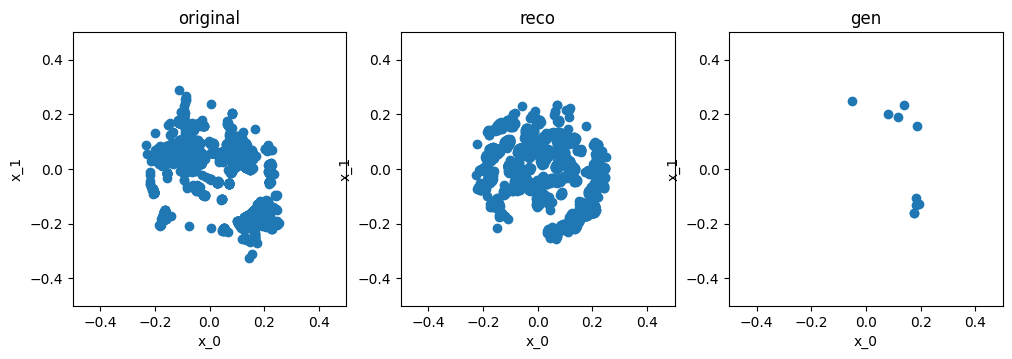

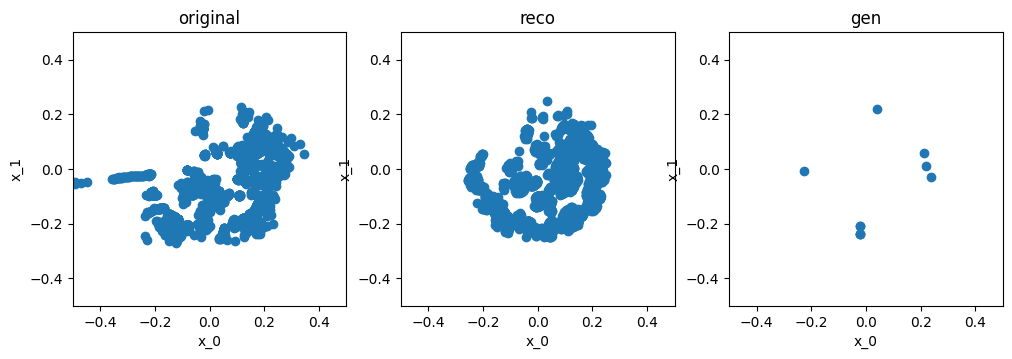

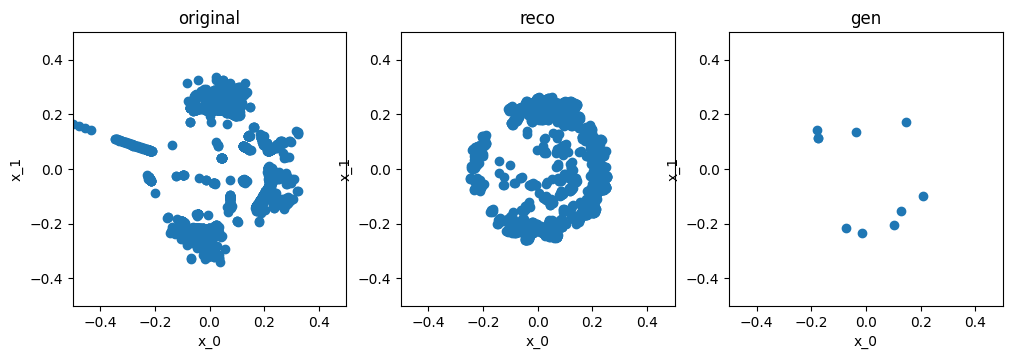

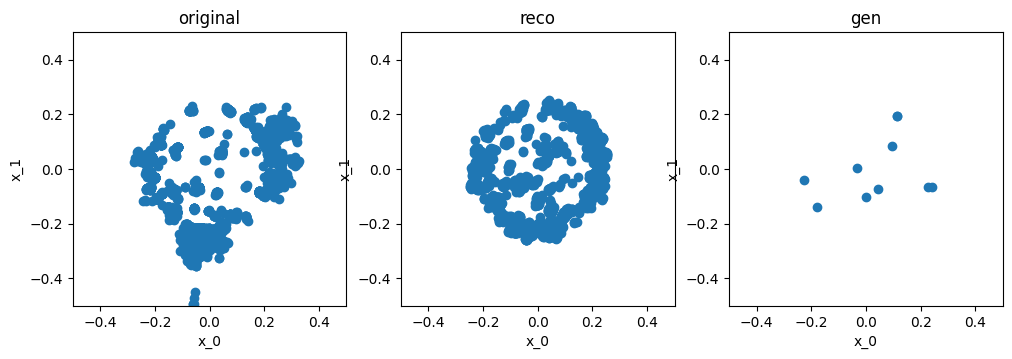

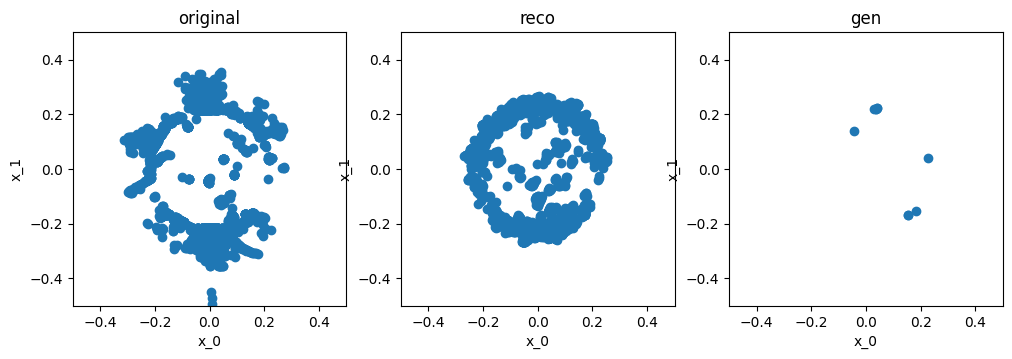

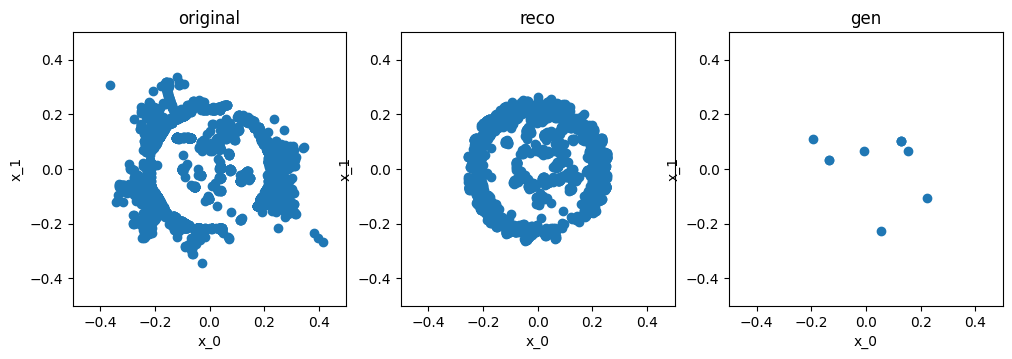

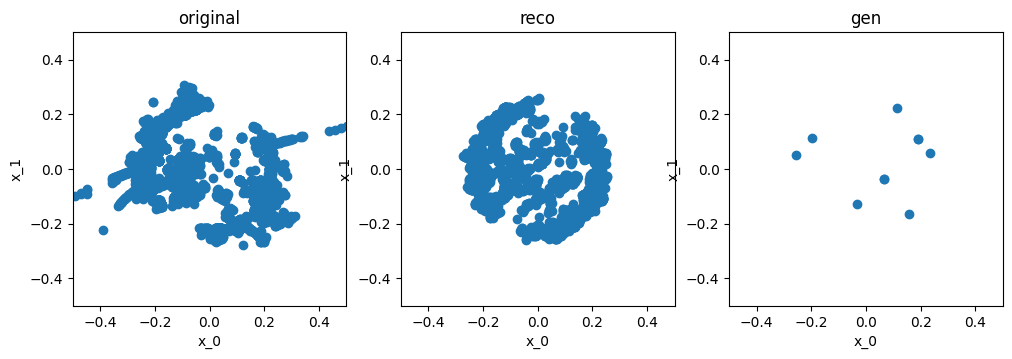

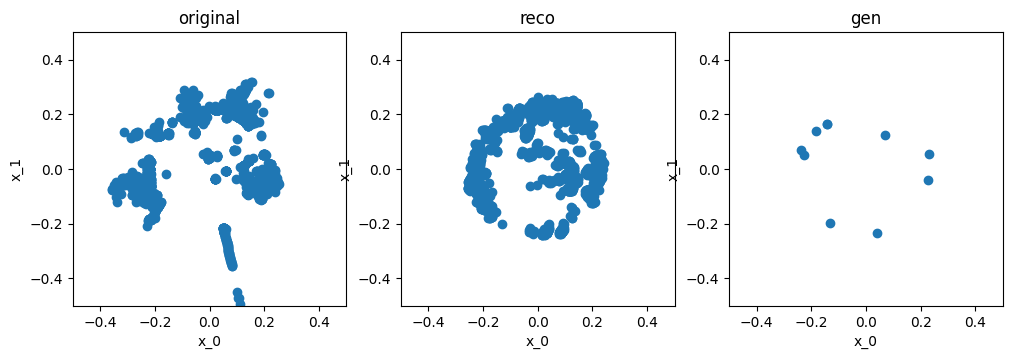

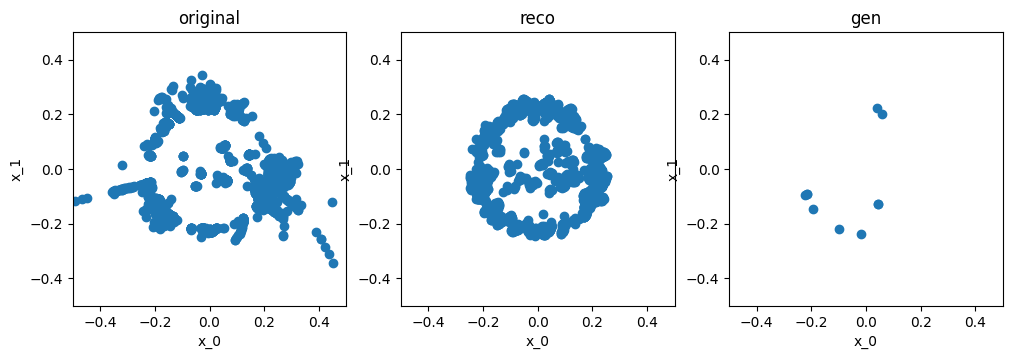

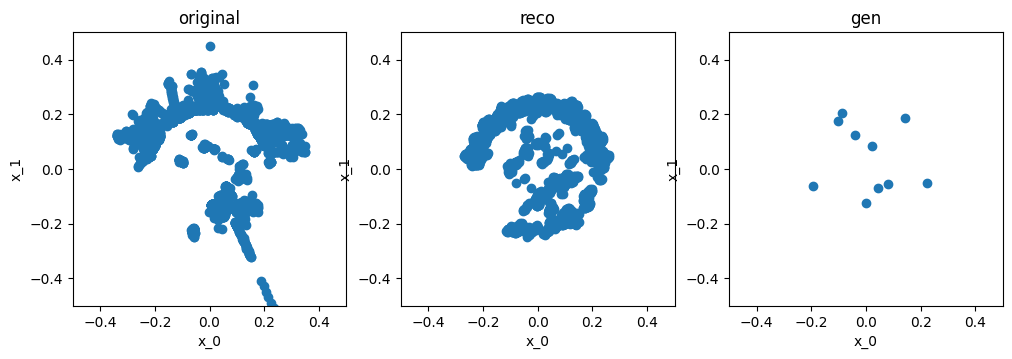

In [52]:
ind_0, ind_1 = 0, 1

for i in range(10):

    fig, ax = plt.subplots(1, 3, figsize = (12, 4))

    for a in ax:
        a.set_box_aspect(1)   # <-- TRUE SQUARE SUBPLOT BOX
        a.set_xlim(-position_lim, position_lim)
        a.set_ylim(-position_lim, position_lim)
    
    ax[0].scatter(features_original[ind_0][i], features_original[ind_1][i])
    ax[0].set_xlabel(f"x_{ind_0}")
    ax[0].set_ylabel(f"x_{ind_1}")
    ax[0].set_title("original")
    
    ax[1].scatter(features_reconstructed[ind_0][i], features_reconstructed[ind_1][i])
    ax[1].set_xlabel(f"x_{ind_0}")
    ax[1].set_ylabel(f"x_{ind_1}")
    ax[1].set_title("reco")

    ax[2].scatter(features_generated[ind_0][i], features_generated[ind_1][i])
    ax[2].set_xlabel(f"x_{ind_0}")
    ax[2].set_ylabel(f"x_{ind_1}")
    ax[2].set_title("gen")
    
    plt.show()


